# Regression Analysis – Auto MPG Dataset

In this part of the project we analyze a supervised regression problem
using the Auto MPG dataset. The goal is to predict a car's fuel efficiency
(measured in miles per gallon – mpg) based on several vehicle characteristics
such as weight, horsepower, and number of cylinders.

We begin with an exploratory data analysis (EDA) to understand the structure
of the dataset, examine the distribution of the target variable, and explore
relationships between the features and the target.


## Import Libraries


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [32]:
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

columns = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

df = pd.read_csv(url, delim_whitespace=True, names=columns, na_values="?") ##missing values as ?

df.head()

/tmp/ipykernel_1070/499590778.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, names=columns, na_values="?") ##missing values as ?


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


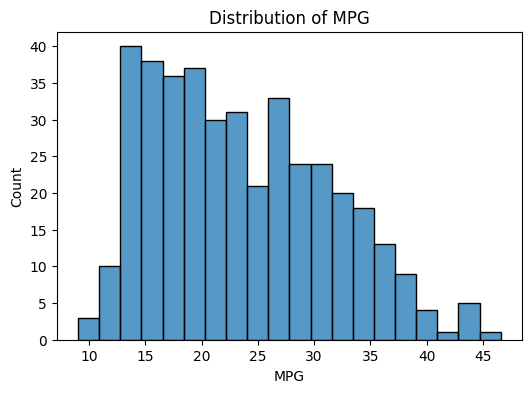

In [33]:
plt.figure(figsize=(6,4))
sns.histplot(df["mpg"], bins=20)
plt.title("Distribution of MPG")
plt.xlabel("MPG")
plt.ylabel("Count")
plt.show()

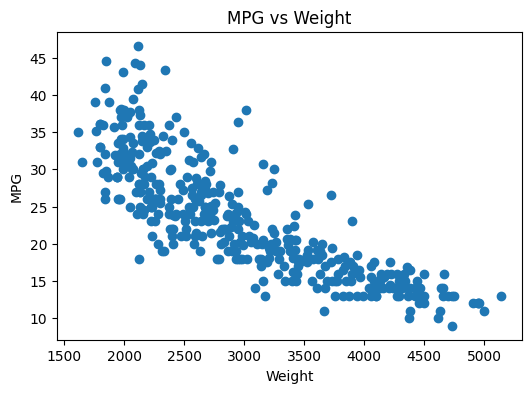

In [34]:
plt.figure(figsize=(6,4))
plt.scatter(df["weight"], df["mpg"])
plt.title("MPG vs Weight")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.show()

### Relationship between Weight and MPG

The scatter plot shows a negative relationship between vehicle weight
and fuel efficiency. As the weight of the car increases, the mpg values
generally decrease. This makes sense since heavier vehicles typically
consume more fuel.This suggests that weight is likely an important feature
for predicting mpg.

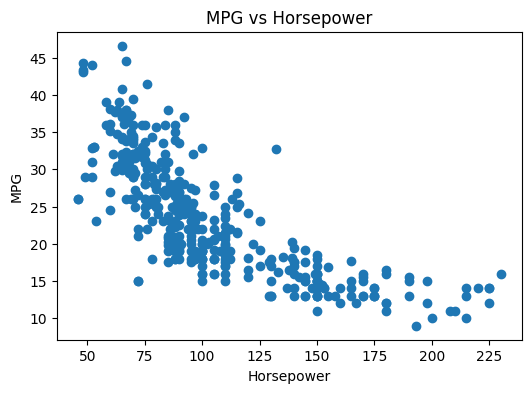

In [35]:
plt.figure(figsize=(6,4))

plt.scatter(df["horsepower"], df["mpg"])

plt.title("MPG vs Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.show()

The scatter plot indicates a negative relationship between horsepower and mpg.
As horsepower increases, fuel efficiency generally decreases.

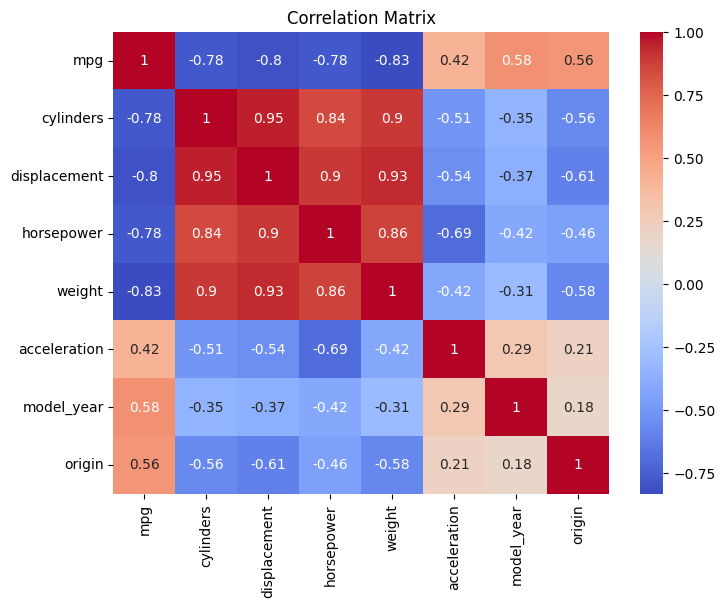

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm") ##calculate only for numbers to find corelation
plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis

The correlation matrix shows the relationships between the variables.
We observe strong negative correlations between mpg and variables such
as weight, horsepower, and cylinders. This suggests that heavier cars
and cars with more powerful engines tend to have lower fuel efficiency.

In [37]:
df.isnull().sum() ##finding missing values

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


In [38]:
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median()) ##if there is missing values replace it with median


In [39]:
df.isnull().sum() ##finding missing values after ths change

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


### Handling Missing Values

The "horsepower" column contains 6 missing values.  
These values were replaced with the median of the column.